# Notebook — Teste do módulo `ellipsoid.py`

Este notebook testa o módulo:

```python
geodesy/ellipsoid.py
```

O objetivo é verificar as funções ligadas à geometria do elipsoide de referência:

- semi-eixo menor;
- primeira excentricidade;
- segunda excentricidade;
- excentricidade linear;
- raio de curvatura no primeiro vertical;
- raio de curvatura meridiano;
- raio médio de curvatura;
- raio geocêntrico;
- latitude geocêntrica;
- latitude reduzida;
- raio authálico aproximado;
- resumo dos parâmetros do elipsoide.

Os gráficos são chamados diretamente nas células, usando `plot`, `scatter`, `bar` e comparações simples.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Este notebook assume que a pasta "geodesy" está no mesmo diretório do notebook.
current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook na mesma pasta onde está a pasta geodesy/.")

import geodesy
from geodesy import constants
from geodesy import ellipsoid

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Semi-eixo menor

O semi-eixo menor é calculado por:

\[
b = a(1-f)
\]

em que \(a\) é o semi-eixo maior e \(f\) é o achatamento.


Semi-eixo menor WGS84: 6356752.314245179 m
Semi-eixo menor GRS80: 6356752.314140356 m
Diferença WGS84 - GRS80: 0.00010482314974069595 m


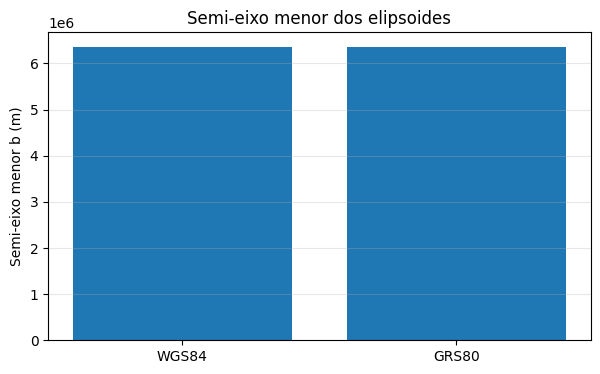

In [2]:
# ============================================================
# 1. SEMI-EIXO MENOR
# ============================================================

b_wgs84 = ellipsoid.semi_minor_axis(constants.WGS84_A, constants.WGS84_F)
b_grs80 = ellipsoid.semi_minor_axis(constants.GRS80_A, constants.GRS80_F)

print("Semi-eixo menor WGS84:", b_wgs84, "m")
print("Semi-eixo menor GRS80:", b_grs80, "m")
print("Diferença WGS84 - GRS80:", b_wgs84 - b_grs80, "m")

plt.figure(figsize=(7, 4))
plt.bar(["WGS84", "GRS80"], [b_wgs84, b_grs80])
plt.ylabel("Semi-eixo menor b (m)")
plt.title("Semi-eixo menor dos elipsoides")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 2. Excentricidades do elipsoide

Vamos testar:

\[
e^2 = 2f - f^2
\]

e a segunda excentricidade:

\[
e'^2 = \frac{e^2}{1-e^2}.
\]


In [3]:
# ============================================================
# 2. EXCENTRICIDADES
# ============================================================

e2_wgs84 = ellipsoid.first_eccentricity_squared(constants.WGS84_F)
e_wgs84 = ellipsoid.first_eccentricity(constants.WGS84_F)

ep2_wgs84 = ellipsoid.second_eccentricity_squared(constants.WGS84_F)
ep_wgs84 = ellipsoid.second_eccentricity(constants.WGS84_F)

print("WGS84:")
print("e²:", e2_wgs84)
print("e:", e_wgs84)
print("e'²:", ep2_wgs84)
print("e':", ep_wgs84)

e2_grs80 = ellipsoid.first_eccentricity_squared(constants.GRS80_F)
e_grs80 = ellipsoid.first_eccentricity(constants.GRS80_F)

ep2_grs80 = ellipsoid.second_eccentricity_squared(constants.GRS80_F)
ep_grs80 = ellipsoid.second_eccentricity(constants.GRS80_F)

print("\nGRS80:")
print("e²:", e2_grs80)
print("e:", e_grs80)
print("e'²:", ep2_grs80)
print("e':", ep_grs80)


WGS84:
e²: 0.0066943799901413165
e: 0.08181919084262149
e'²: 0.006739496742276434
e': 0.08209443794969568

GRS80:
e²: 0.006694380022900787
e: 0.08181919104281579
e'²: 0.006739496775478957
e': 0.08209443815191719


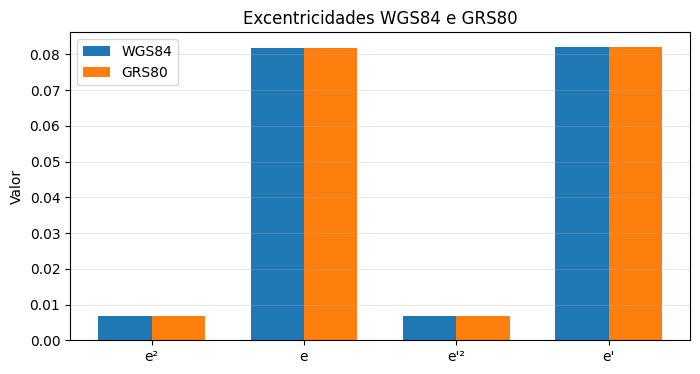

In [4]:
# Comparação gráfica das excentricidades

labels = ["e²", "e", "e'²", "e'"]
wgs_values = [e2_wgs84, e_wgs84, ep2_wgs84, ep_wgs84]
grs_values = [e2_grs80, e_grs80, ep2_grs80, ep_grs80]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, wgs_values, width, label="WGS84")
plt.bar(x + width/2, grs_values, width, label="GRS80")
plt.xticks(x, labels)
plt.ylabel("Valor")
plt.title("Excentricidades WGS84 e GRS80")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## 3. Excentricidade linear

A excentricidade linear é:

\[
E = \sqrt{a^2-b^2}.
\]


In [5]:
# ============================================================
# 3. EXCENTRICIDADE LINEAR
# ============================================================

E_wgs84 = ellipsoid.linear_eccentricity(constants.WGS84_A, constants.WGS84_F)
E_grs80 = ellipsoid.linear_eccentricity(constants.GRS80_A, constants.GRS80_F)

print("Excentricidade linear WGS84:", E_wgs84, "m")
print("Excentricidade linear GRS80:", E_grs80, "m")
print("Diferença:", E_wgs84 - E_grs80, "m")


Excentricidade linear WGS84: 521854.00842338527 m
Excentricidade linear GRS80: 521854.009700248 m
Diferença: -0.001276862749364227 m


## 4. Raios de curvatura em função da latitude

Serão calculados:

- \(N\): raio de curvatura no primeiro vertical;
- \(M\): raio de curvatura meridiano;
- \(\sqrt{MN}\): raio médio de curvatura.


N no Equador: 6378137.0 m
N no Polo: 6399593.625758493 m

M no Equador: 6335439.3272928195 m
M no Polo: 6399593.625758492 m


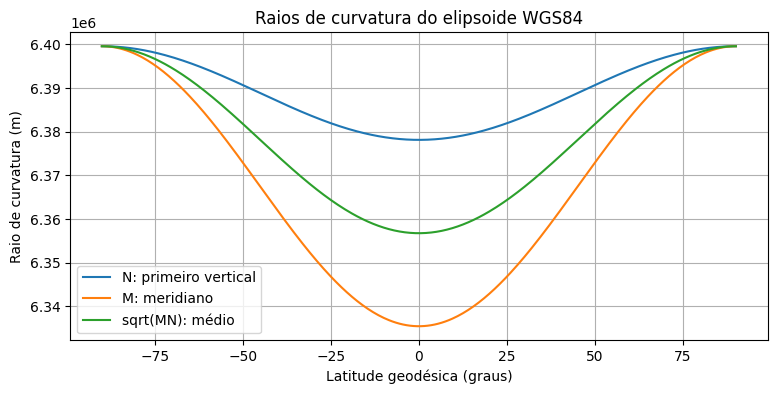

In [6]:
# ============================================================
# 4. RAIOS DE CURVATURA
# ============================================================

lat = np.linspace(-90, 90, 361)

N = ellipsoid.prime_vertical_radius(lat)
M = ellipsoid.meridian_radius(lat)
Rmean = ellipsoid.mean_radius_of_curvature(lat)

print("N no Equador:", ellipsoid.prime_vertical_radius(0.0), "m")
print("N no Polo:", ellipsoid.prime_vertical_radius(90.0), "m")

print("\nM no Equador:", ellipsoid.meridian_radius(0.0), "m")
print("M no Polo:", ellipsoid.meridian_radius(90.0), "m")

plt.figure(figsize=(9, 4))
plt.plot(lat, N, label="N: primeiro vertical")
plt.plot(lat, M, label="M: meridiano")
plt.plot(lat, Rmean, label="sqrt(MN): médio")
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Raio de curvatura (m)")
plt.title("Raios de curvatura do elipsoide WGS84")
plt.legend()
plt.grid(True)
plt.show()


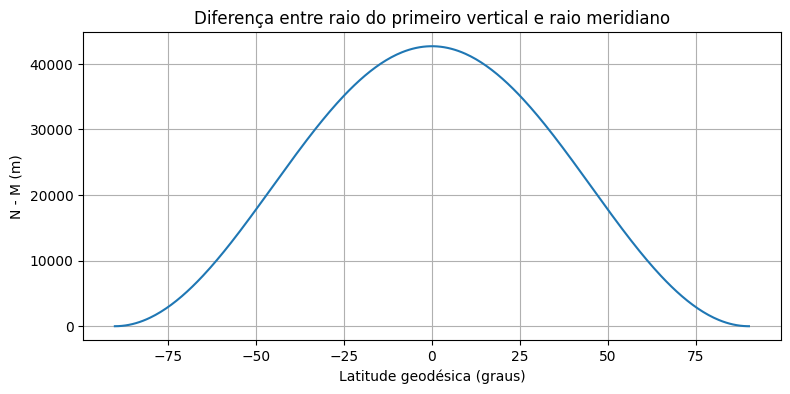

Diferença máxima N-M: 42697.67270718049 m
Diferença mínima N-M: 9.313225746154785e-10 m


In [7]:
# Diferença entre N e M

plt.figure(figsize=(9, 4))
plt.plot(lat, N - M)
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("N - M (m)")
plt.title("Diferença entre raio do primeiro vertical e raio meridiano")
plt.grid(True)
plt.show()

print("Diferença máxima N-M:", np.nanmax(N-M), "m")
print("Diferença mínima N-M:", np.nanmin(N-M), "m")


## 5. Raio geocêntrico

O raio geocêntrico do elipsoide varia com a latitude, sendo maior no equador e menor nos polos.


Raio geocêntrico no Equador: 6378137.0 m
Raio geocêntrico em 45 graus: 6367489.543863466 m
Raio geocêntrico no Polo: 6356752.314245179 m


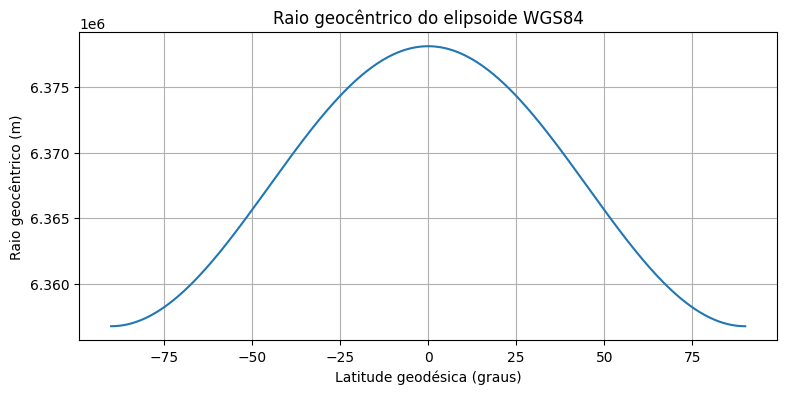

In [8]:
# ============================================================
# 5. RAIO GEOCÊNTRICO
# ============================================================

R_geo = ellipsoid.geocentric_radius(lat)

print("Raio geocêntrico no Equador:", ellipsoid.geocentric_radius(0.0), "m")
print("Raio geocêntrico em 45 graus:", ellipsoid.geocentric_radius(45.0), "m")
print("Raio geocêntrico no Polo:", ellipsoid.geocentric_radius(90.0), "m")

plt.figure(figsize=(9, 4))
plt.plot(lat, R_geo)
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Raio geocêntrico (m)")
plt.title("Raio geocêntrico do elipsoide WGS84")
plt.grid(True)
plt.show()


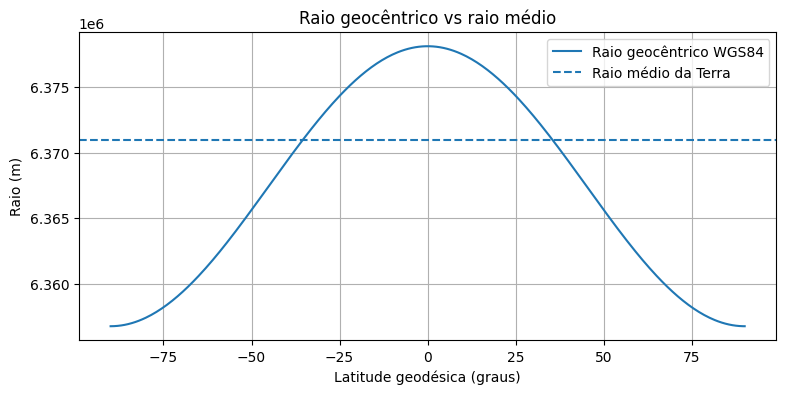

In [9]:
# Comparação com uma esfera de raio médio

plt.figure(figsize=(9, 4))
plt.plot(lat, R_geo, label="Raio geocêntrico WGS84")
plt.axhline(constants.MEAN_EARTH_RADIUS, linestyle="--", label="Raio médio da Terra")
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Raio (m)")
plt.title("Raio geocêntrico vs raio médio")
plt.legend()
plt.grid(True)
plt.show()


## 6. Latitude geodésica, geocêntrica e reduzida

Agora vamos comparar:

- latitude geodésica \(\phi\);
- latitude geocêntrica;
- latitude reduzida ou paramétrica.


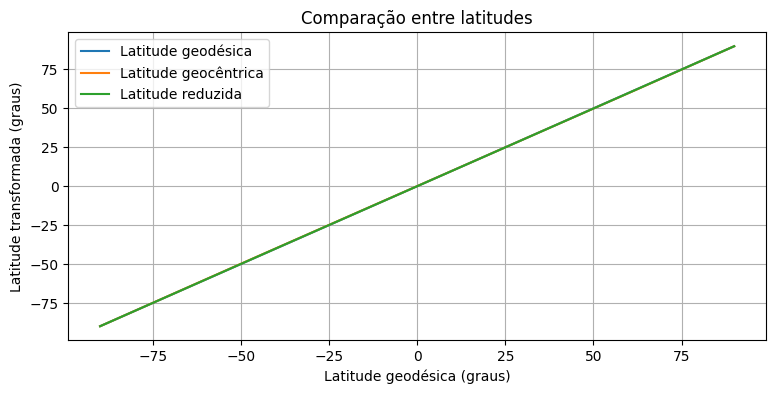

In [10]:
# ============================================================
# 6. LATITUDES GEODÉSICA, GEOCÊNTRICA E REDUZIDA
# ============================================================

lat_geod = np.linspace(-89.9, 89.9, 400)

lat_gc = ellipsoid.geocentric_latitude(lat_geod)
lat_red = ellipsoid.reduced_latitude(lat_geod)

plt.figure(figsize=(9, 4))
plt.plot(lat_geod, lat_geod, label="Latitude geodésica")
plt.plot(lat_geod, lat_gc, label="Latitude geocêntrica")
plt.plot(lat_geod, lat_red, label="Latitude reduzida")
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Latitude transformada (graus)")
plt.title("Comparação entre latitudes")
plt.legend()
plt.grid(True)
plt.show()


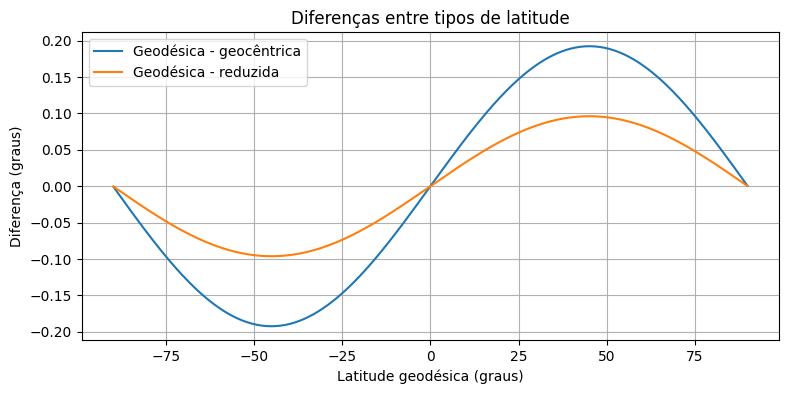

Maior diferença geodésica-geocêntrica:
Latitude: 45.287969924812046
Diferença: 0.19241999033465618 graus


In [11]:
# Diferenças entre as latitudes

plt.figure(figsize=(9, 4))
plt.plot(lat_geod, lat_geod - lat_gc, label="Geodésica - geocêntrica")
plt.plot(lat_geod, lat_geod - lat_red, label="Geodésica - reduzida")
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Diferença (graus)")
plt.title("Diferenças entre tipos de latitude")
plt.legend()
plt.grid(True)
plt.show()

idx_max = np.argmax(np.abs(lat_geod - lat_gc))
print("Maior diferença geodésica-geocêntrica:")
print("Latitude:", lat_geod[idx_max])
print("Diferença:", (lat_geod - lat_gc)[idx_max], "graus")


## 7. Raio authálico aproximado

O raio authálico corresponde ao raio da esfera com a mesma área superficial do elipsoide.


Raio authálico aproximado: 6371007.180918474 m
Raio médio definido no constants.py: 6371008.8 m
Diferença: -1.6190815260633826 m


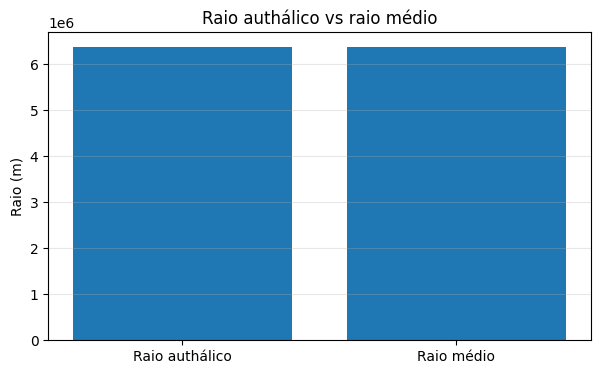

In [12]:
# ============================================================
# 7. RAIO AUTHÁLICO APROXIMADO
# ============================================================

R_auth = ellipsoid.authalic_radius()

print("Raio authálico aproximado:", R_auth, "m")
print("Raio médio definido no constants.py:", constants.MEAN_EARTH_RADIUS, "m")
print("Diferença:", R_auth - constants.MEAN_EARTH_RADIUS, "m")

plt.figure(figsize=(7, 4))
plt.bar(["Raio authálico", "Raio médio"], [R_auth, constants.MEAN_EARTH_RADIUS])
plt.ylabel("Raio (m)")
plt.title("Raio authálico vs raio médio")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 8. Resumo completo do elipsoide

A função `ellipsoid_summary` retorna um dicionário com os principais parâmetros do elipsoide.


In [13]:
# ============================================================
# 8. RESUMO DO ELIPSOIDE
# ============================================================

summary_wgs84 = ellipsoid.ellipsoid_summary()
summary_grs80 = ellipsoid.ellipsoid_summary(a=constants.GRS80_A, f=constants.GRS80_F)

print("Resumo WGS84:")
for k, v in summary_wgs84.items():
    print(f"{k}: {v}")

print("\nResumo GRS80:")
for k, v in summary_grs80.items():
    print(f"{k}: {v}")


Resumo WGS84:
a: 6378137.0
b: 6356752.314245179
f: 0.0033528106647474805
e2: 0.0066943799901413165
e: 0.08181919084262149
ep2: 0.006739496742276434
ep: 0.08209443794969568
linear_eccentricity: 521854.00842338527

Resumo GRS80:
a: 6378137.0
b: 6356752.314140356
f: 0.003352810681182319
e2: 0.006694380022900787
e: 0.08181919104281579
ep2: 0.006739496775478957
ep: 0.08209443815191719
linear_eccentricity: 521854.009700248


## 9. Mapa simples latitude × raio geocêntrico

Aqui usamos `scatter` para visualizar a variação discreta do raio geocêntrico em latitudes específicas.


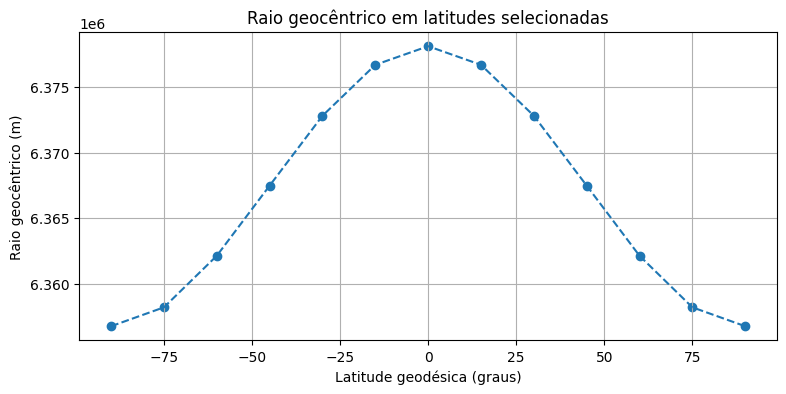

Latitude  -90.0 graus -> R = 6356752.314 m
Latitude  -75.0 graus -> R = 6358196.081 m
Latitude  -60.0 graus -> R = 6362132.224 m
Latitude  -45.0 graus -> R = 6367489.544 m
Latitude  -30.0 graus -> R = 6372824.420 m
Latitude  -15.0 graus -> R = 6376715.677 m
Latitude    0.0 graus -> R = 6378137.000 m
Latitude   15.0 graus -> R = 6376715.677 m
Latitude   30.0 graus -> R = 6372824.420 m
Latitude   45.0 graus -> R = 6367489.544 m
Latitude   60.0 graus -> R = 6362132.224 m
Latitude   75.0 graus -> R = 6358196.081 m
Latitude   90.0 graus -> R = 6356752.314 m


In [14]:
# ============================================================
# 9. SCATTER: LATITUDE VS RAIO GEOCÊNTRICO
# ============================================================

lat_points = np.array([-90, -75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75, 90], dtype=float)
R_points = ellipsoid.geocentric_radius(lat_points)

plt.figure(figsize=(9, 4))
plt.scatter(lat_points, R_points)
plt.plot(lat_points, R_points, linestyle="--")
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Raio geocêntrico (m)")
plt.title("Raio geocêntrico em latitudes selecionadas")
plt.grid(True)
plt.show()

for la, rr in zip(lat_points, R_points):
    print(f"Latitude {la:6.1f} graus -> R = {rr:.3f} m")


## 10. Contorno didático: raio geocêntrico em função de latitude e longitude

O raio geocêntrico do elipsoide depende da latitude, não da longitude. Mesmo assim, podemos gerar uma malha latitude-longitude e usar `contourf` para visualizar esse comportamento em mapa retangular.


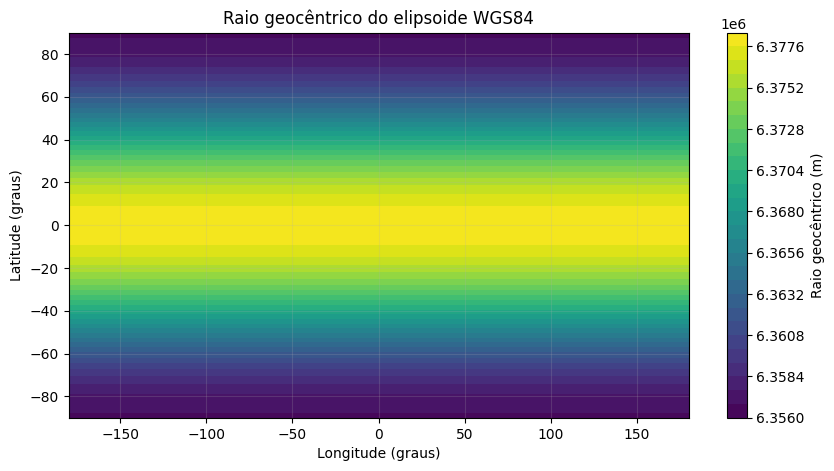

In [15]:
# ============================================================
# 10. CONTOURF DIDÁTICO DO RAIO GEOCÊNTRICO
# ============================================================

lon_grid = np.linspace(-180, 180, 361)
lat_grid = np.linspace(-90, 90, 181)

LON, LAT = np.meshgrid(lon_grid, lat_grid)
R_GRID = ellipsoid.geocentric_radius(LAT)

plt.figure(figsize=(10, 5))
c = plt.contourf(LON, LAT, R_GRID, levels=30)
plt.colorbar(c, label="Raio geocêntrico (m)")
plt.xlabel("Longitude (graus)")
plt.ylabel("Latitude (graus)")
plt.title("Raio geocêntrico do elipsoide WGS84")
plt.grid(alpha=0.2)
plt.show()


## 11. Teste com entrada vetorial e escalar

As funções devem funcionar tanto com valores escalares quanto com vetores.


In [16]:
# ============================================================
# 11. TESTE ESCALAR E VETORIAL
# ============================================================

lat_scalar = 45.0
lat_vector = np.array([0.0, 30.0, 45.0, 60.0, 90.0])

print("Entrada escalar:")
print("N =", ellipsoid.prime_vertical_radius(lat_scalar))
print("M =", ellipsoid.meridian_radius(lat_scalar))
print("R =", ellipsoid.geocentric_radius(lat_scalar))

print("\nEntrada vetorial:")
print("Latitudes:", lat_vector)
print("N =", ellipsoid.prime_vertical_radius(lat_vector))
print("M =", ellipsoid.meridian_radius(lat_vector))
print("R =", ellipsoid.geocentric_radius(lat_vector))


Entrada escalar:
N = 6388838.290121148
M = 6367381.815619548
R = 6367489.543863466

Entrada vetorial:
Latitudes: [ 0. 30. 45. 60. 90.]
N = [6378137.         6383480.91769011 6388838.29012115 6394209.17384789
 6399593.62575849]
M = [6335439.32729282 6351377.10371551 6367381.81561955 6383453.85722908
 6399593.62575849]
R = [6378137.         6372824.42029401 6367489.54386347 6362132.2243971
 6356752.31424518]


## 12. Resumo final

Se todas as células foram executadas sem erro, o módulo `ellipsoid.py` está funcionando corretamente.

No próximo notebook, testaremos o módulo:

```python
geodesy/coordinates.py
```

com transformações entre latitude/longitude/altura, ECEF e ENU.
